# ЛАБОРАТОРНА РОБОТА 1
## Лінійна регресія

In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

## **1. Підготовчий етап**
### 1.1 Провести аналіз вибраного набору даних

In [242]:
# Load the dataset from the CSV file.
df = pd.read_csv('train.csv')

print("Розмір датасету:", df.shape)
display(df.head())

Розмір датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [243]:
# Select numerical columns.
numeric_columns = df.select_dtypes(include=np.number).columns

# Select categorical columns.
categorical_columns = df.select_dtypes(include='object').columns

print("Кількість числових ознак:", len(numeric_columns))
print("Кількість категоріальних ознак:", len(categorical_columns))

print("\nЧислові ознаки:")
print(list(numeric_columns))

print("\nКатегоріальні features:")
print(list(categorical_columns))

Кількість числових ознак: 38
Кількість категоріальних ознак: 43

Числові ознаки:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Категоріальні features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', '

### 1.2 Визначити вхідні та вихідні параметри

In [244]:
# Create the input data without the ID and target column.
X = df.drop(columns=['Id', 'SalePrice'])

# Create the target data.
y = df['SalePrice']

print("Вхідні дані X:", X.shape)
print("Вихідні дані y:", y.shape)

Вхідні дані X: (1460, 79)
Вихідні дані y: (1460,)


### 1.3 Візуалізувати залежності входів та виходу

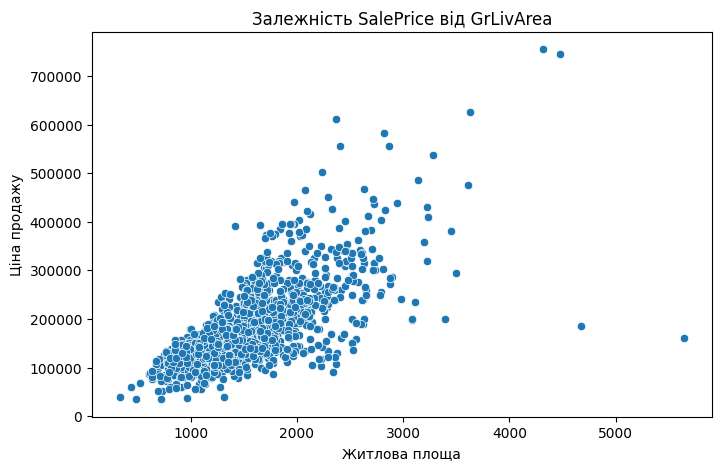

In [245]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='SalePrice'
)

plt.title('Залежність SalePrice від GrLivArea')
plt.xlabel('Житлова площа')
plt.ylabel('Ціна продажу')
plt.show()

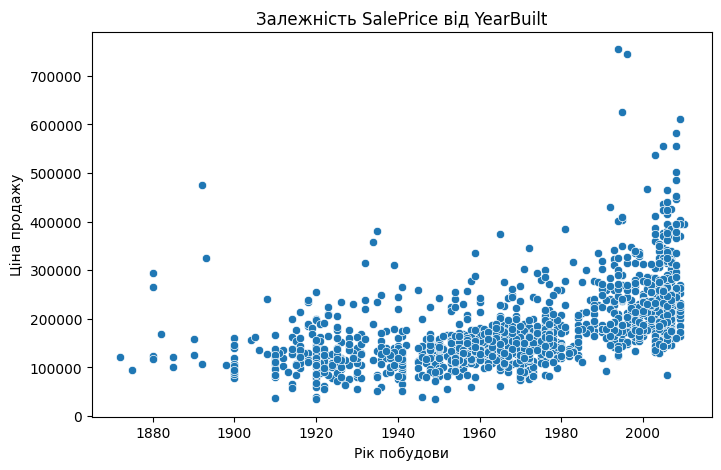

In [246]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='YearBuilt',
    y='SalePrice'
)

plt.title('Залежність SalePrice від YearBuilt')
plt.xlabel('Рік побудови')
plt.ylabel('Ціна продажу')
plt.show()

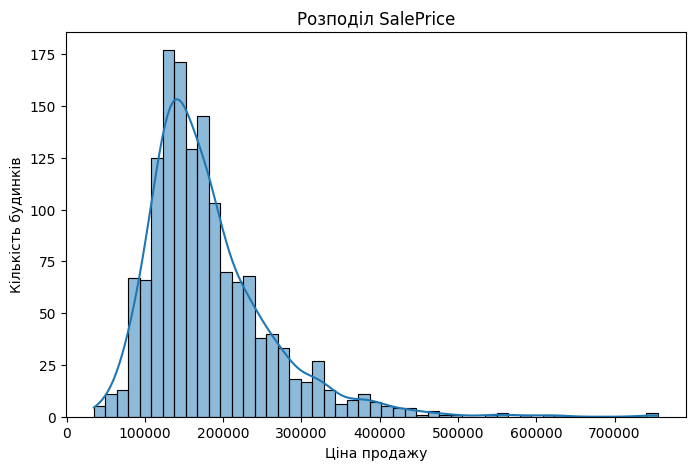

In [247]:
plt.figure(figsize=(8, 5))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Розподіл SalePrice')
plt.xlabel('Ціна продажу')
plt.ylabel('Кількість будинків')
plt.show()

### 1.4 Виявлення аномалій та неповних зразків

In [248]:
# Count missing values in each column.
missing = df.isnull().sum()

# Keep only columns with missing values.
missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [249]:
# Count duplicate rows.
duplicates = df.duplicated().sum()

print("Кількість дублікатів:", duplicates)

Кількість дублікатів: 0


### 1.5 Кореляційний аналіз

In [250]:
# Select only numerical columns.
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation between the numerical columns.
correlation = numeric_df.corr()

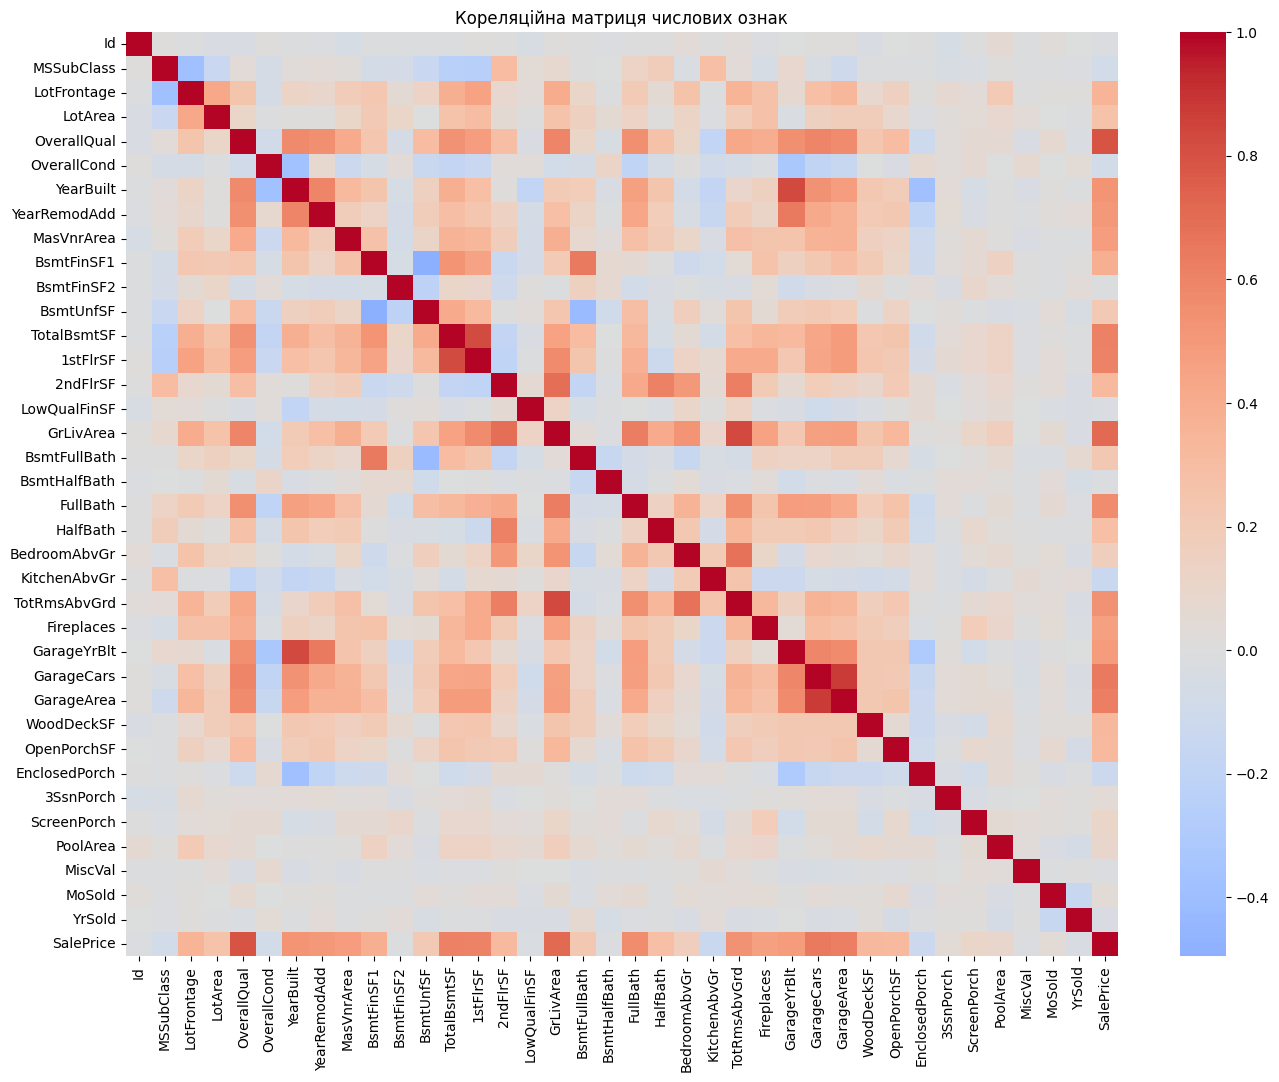

In [251]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Кореляційна матриця числових ознак')
plt.show()

In [252]:
# Get the correlation of all features with SalePrice.
saleprice_corr = correlation['SalePrice'].sort_values(
    ascending=False
)

display(saleprice_corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [253]:
# Find the 16 features with the strongest correlation.
top_corr = saleprice_corr.abs().sort_values( ascending=False).head(16)

# Display their correlation with SalePrice.
display(correlation.loc[top_corr.index, ['SalePrice']])

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


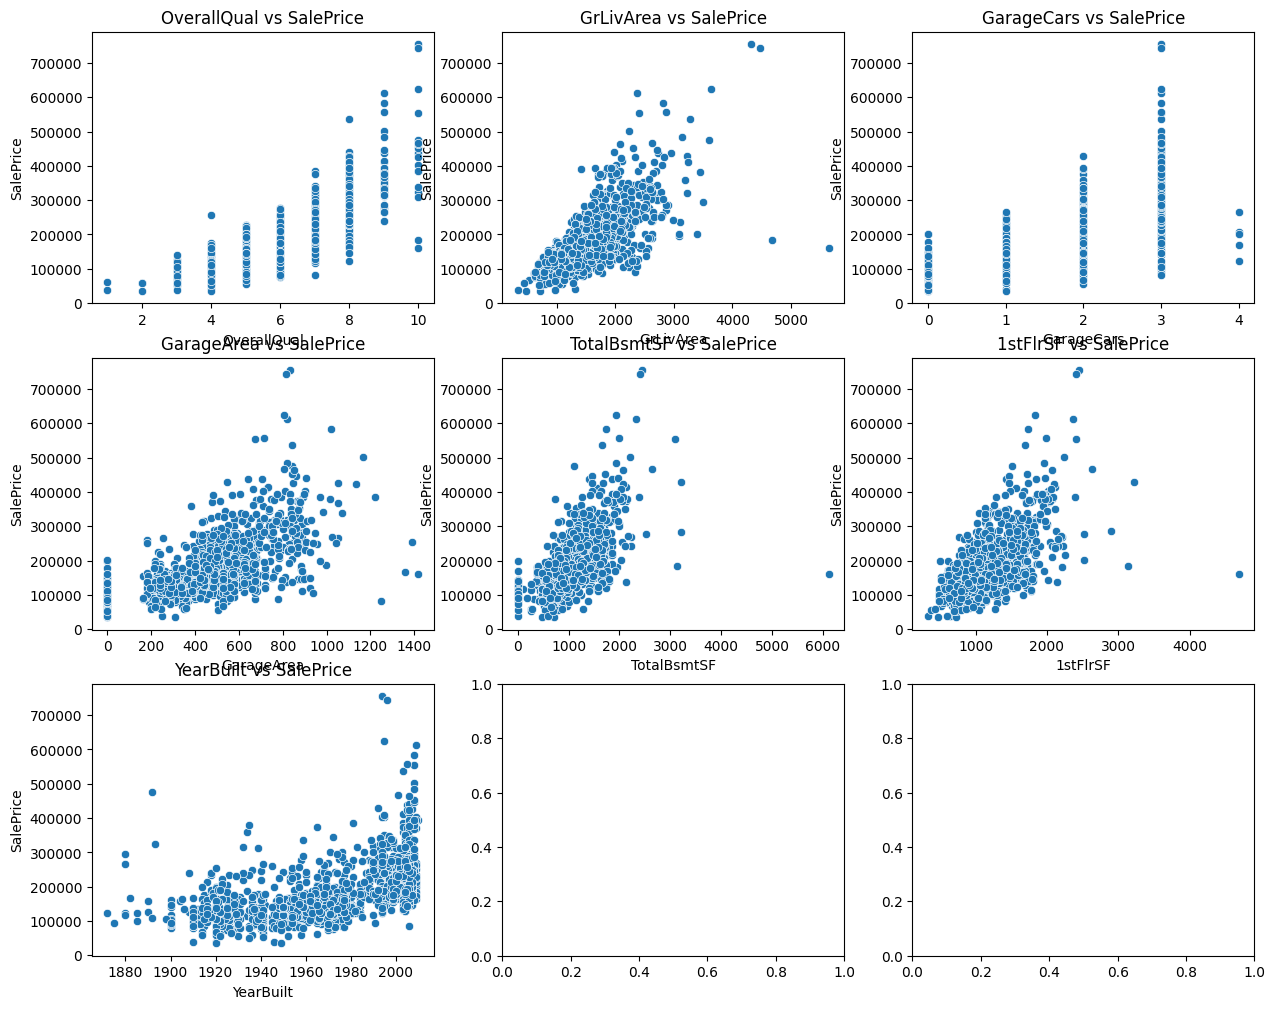

In [254]:
# Select the main features.
top_features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'YearBuilt'
]

# Create a grid for the plots.
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Create a scatter plot for each feature.
for ax, feature in zip(axes.flat, top_features):
    sns.scatterplot(
        data=df,
        x=feature,
        y='SalePrice',
        ax=ax
    )

    # Add the plot title.
    ax.set_title(f'{feature} vs SalePrice')

### 1.6 Підготовка даних

In [255]:
# Remove the ID column from the dataset.
df_clean = df.drop(columns=['Id']).copy()

In [256]:
# Create the input data without the target column.
X = df_clean.drop(columns=['SalePrice'])

# Create the target data.
y = df_clean['SalePrice']

In [257]:
# Select categorical features.
categorical_features = X.select_dtypes(include='object').columns

# Print the number of categorical features.
print("Категоріальних ознак:", len(categorical_features))

Категоріальних ознак: 43


In [258]:
# Fill missing categorical values with 'None'.
X[categorical_features] = X[categorical_features].fillna('None')

In [259]:
# Select numerical features.
numeric_features = X.select_dtypes(include=np.number).columns

# Fill missing numerical values with the median.
X[numeric_features] = X[numeric_features].fillna( X[numeric_features].median())

In [260]:
print("Загальна кількість пропусків:", X.isnull().sum().sum())

Загальна кількість пропусків: 0


In [261]:
# Convert categorical features into numerical columns.
X = pd.get_dummies( X, columns=categorical_features, drop_first=False)

In [262]:
print("Розмір X після кодування:", X.shape)
print("Типи даних:")
print(X.dtypes.value_counts())

Розмір X після кодування: (1460, 303)
Типи даних:
bool       267
int64       33
float64      3
Name: count, dtype: int64


### 1.7 Розбиття на навчальну та тестову частини

In [263]:
# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [264]:
# Get the mean of each feature from the training data.
X_mean = X_train.mean()

# Get the standard deviation of each feature from the training data.
X_std = X_train.std()

# Replace zero values with 1 to avoid division by zero.
X_std[X_std == 0] = 1

# Scale the training data.
X_train_scaled = (X_train - X_mean) / X_std

# Scale the test data using the same values.
X_test_scaled = (X_test - X_mean) / X_std

# Convert training data to NumPy arrays.
X_train_np = X_train_scaled.to_numpy(dtype=float)

# Convert test data to a NumPy array.
X_test_np = X_test_scaled.to_numpy(dtype=float)

# Convert training target data to a NumPy array.
y_train_np = y_train.to_numpy(dtype=float)

# Convert test target data to a NumPy array.
y_test_np = y_test.to_numpy(dtype=float)

# Print the array shapes.
print("X_train:", X_train_np.shape)
print("X_test:", X_test_np.shape)
print("y_train:", y_train_np.shape)
print("y_test:", y_test_np.shape)

X_train: (1022, 303)
X_test: (438, 303)
y_train: (1022,)
y_test: (438,)


In [265]:
# Calculate the mean squared error.
def mse(y_true, y_pred):
    # Find the difference between true and predicted values.
    error = y_true - y_pred

    # Square the errors and find their mean.
    return np.mean(error ** 2)


# Calculate the root mean squared error.
def rmse(y_true, y_pred):
    # Take the square root of MSE.
    return np.sqrt(mse(y_true, y_pred))


# Calculate the mean absolute error.
def mae(y_true, y_pred):
    # Find the absolute errors.
    error = np.abs(y_true - y_pred)

    # Find the mean of the errors.
    return np.mean(error)


# Calculate the R-squared score.
def r2_score(y_true, y_pred):
    # Calculate the sum of squared errors.
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Calculate the total sum of squares.
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    # Return the R-squared score.
    return 1 - ss_res / ss_tot

In [266]:
def evaluate_model(model_name, y_train, pred_train, y_test, pred_test, runtime):
    
    # Create a result dictionary.
    return {
        "Model": model_name,
        "Train MSE": mse(y_train, pred_train),
        "Test MSE": mse(y_test, pred_test),
        "Train RMSE": rmse(y_train, pred_train),
        "Test RMSE": rmse(y_test, pred_test),
        "Train MAE": mae(y_train, pred_train),
        "Test MAE": mae(y_test, pred_test),
        "Train R2": r2_score(y_train, pred_train),
        "Test R2": r2_score(y_test, pred_test),
        "Runtime": runtime
    }

In [267]:
def plot_predictions(y_train, y_train_pred, y_test, y_test_pred, title):
    # Create a figure.
    plt.figure(figsize=(8, 6))

    # Plot actual and predicted values for the training data.
    plt.scatter(y_train, y_train_pred, alpha=0.5, label="Training data")

    # Plot actual and predicted values for the test data.
    plt.scatter( y_test, y_test_pred, alpha=0.5, label="Test data" )

    # Get the minimum and maximum values.
    min_value = min(y_train.min(), y_test.min())
    max_value = max(y_train.max(), y_test.max())

    # Plot the ideal prediction line.
    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Ideal prediction")

    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## **2. Реалізація лінійної регресії**

In [268]:
class MyRegression:
    
    def __init__(self, learning_rate=0.001, epochs=5000, regularization=None, alpha=0.0, l1_ratio=0.5):
        
        # Save the learning rate.
        self.learning_rate = learning_rate
        
        # Save the number of iterations.
        self.epochs = epochs
        
        # Save the regularization type.
        self.regularization = regularization
        
        # Save the regularization strength.
        self.alpha = alpha
        
        # Save the L1 ratio.
        self.l1_ratio = l1_ratio
        
        # Create empty weights.
        self.weights = None
        
        # Create the bias.
        self.bias = 0.0
        
        # Create an empty loss list.
        self.loss_history = []

    def fit(self, X, y):

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):

            # Predictions
            predictions = self.predict(X)

            # Error
            error = predictions - y

            # Gradient
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            # Regularization
            if self.regularization == "l1":

                dw += self.alpha * np.sign(self.weights)

            elif self.regularization == "l2":

                dw += 2 * self.alpha * self.weights

            elif self.regularization == "elastic_net":

                dw += self.alpha * (
                    self.l1_ratio * np.sign(self.weights)
                    + 2 * (1 - self.l1_ratio) * self.weights
                )

            # Update
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # New predictions
            predictions = self.predict(X)
            error = predictions - y

            # MSE
            loss = np.mean(error ** 2)

            # Regularization penalty
            if self.regularization == "l1":

                loss += self.alpha * np.sum(np.abs(self.weights))

            elif self.regularization == "l2":

                loss += self.alpha * np.sum(self.weights ** 2)

            elif self.regularization == "elastic_net":

                loss += self.alpha * (
                    self.l1_ratio * np.sum(np.abs(self.weights))
                    + (1 - self.l1_ratio) * np.sum(self.weights ** 2)
                )

            if not np.isfinite(loss):
                print("Training stopped at epoch:", epoch)
                break

            self.loss_history.append(loss)

        return self

    def predict(self, X):
        
        # Calculate the predictions.
        return np.asarray(X, dtype=np.float64) @ self.weights + self.bias

### 2.1 Створення моделі 

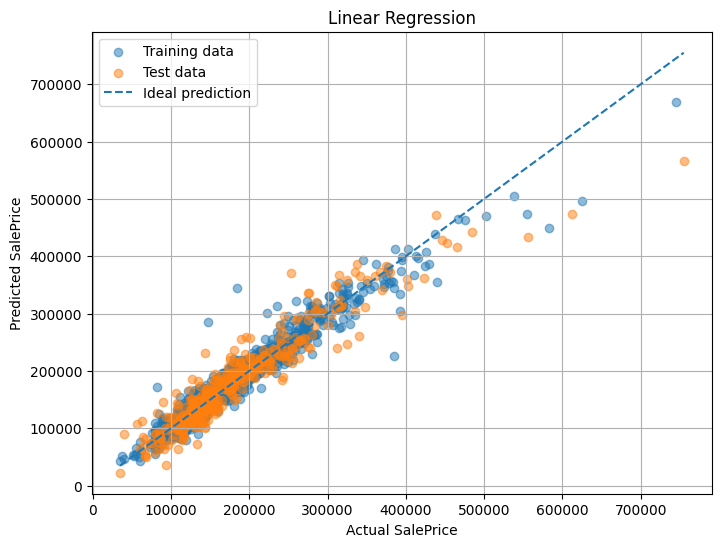

In [269]:
# Create the linear regression model.
linear_regression = MyRegression(learning_rate=0.01, epochs=1000)

# Train the model.
start_time = time.time()
linear_regression.fit(X_train_np, y_train_np)
linear_regression_time = time.time() - start_time

# Predict values for the training data and test data.
y_train_linear_regression = linear_regression.predict(X_train_np)
y_test_linear_regression = linear_regression.predict(X_test_np)

# Plot
plot_predictions( y_train, y_train_linear_regression, y_test, y_test_linear_regression, "Linear Regression")

### 2.2 Створенні моделі з L1-регуляризацією

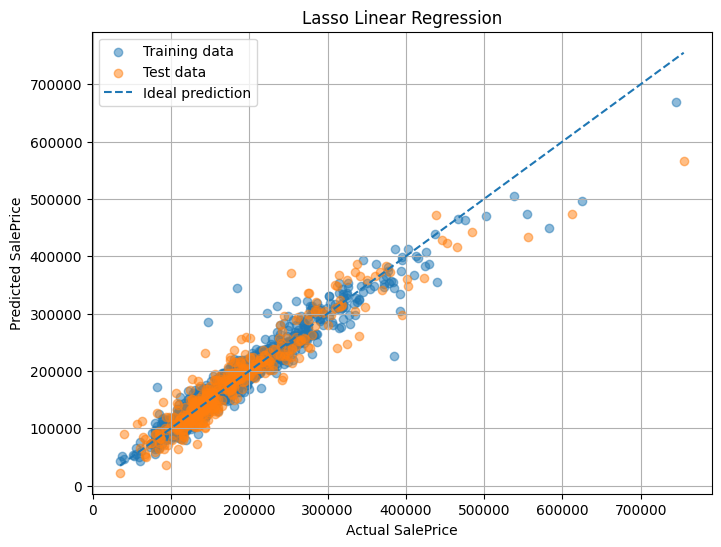

In [270]:
# Create the Lasso regression model.
lasso = MyRegression(learning_rate=0.01, epochs=1000, regularization="l1", alpha=0.01)

# Train the model.
start_time = time.time()
lasso.fit(X_train_np, y_train_np)
lasso_time = time.time() - start_time

# Predict values for the training data and test data.
y_train_lasso = lasso.predict(X_train_np)
y_test_lasso = lasso.predict(X_test_np)

# Plot
plot_predictions( y_train, y_train_lasso, y_test, y_test_lasso, "Lasso Linear Regression")

### 2.3 Створенні моделі з elastic net регуляризацією

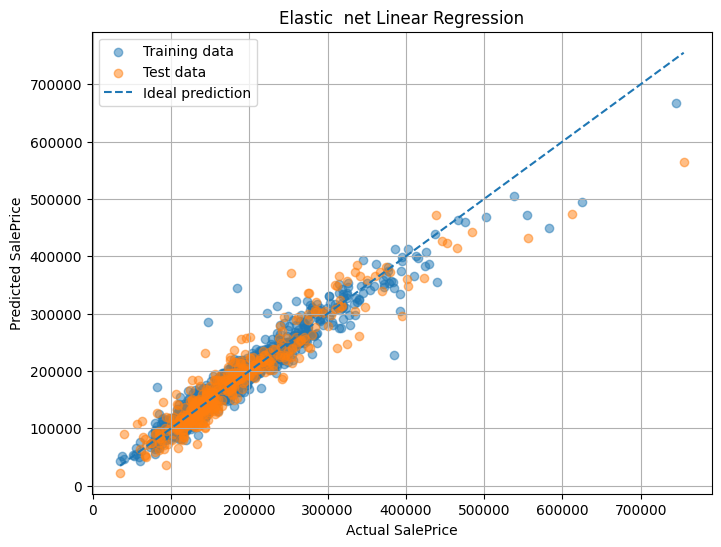

In [271]:
# Create the elastic_net regression model.
elastic_net = MyRegression(learning_rate=0.01, epochs = 1000, regularization="elastic_net", alpha=0.01, l1_ratio=0.5)

# Train the model.
start_time = time.time()
elastic_net.fit(X_train_np, y_train_np)
elastic_time = time.time() - start_time

# Predict values for the training data and test data.
y_train_elastic = elastic_net.predict(X_train_np)
y_test_elastic = elastic_net.predict(X_test_np)

# Plot
plot_predictions( y_train, y_train_elastic, y_test, y_test_elastic, "Elastic  net Linear Regression")

In [272]:
results = []

results.append(
    evaluate_model("linear Regression", y_train, y_train_linear_regression, y_test, y_test_linear_regression, linear_regression_time)
)
results.append(
    evaluate_model("Lasso", y_train, y_train_lasso, y_test, y_test_lasso, lasso_time)
)
results.append(
    evaluate_model( "Elastic Net", y_train, y_train_elastic, y_test, y_test_elastic, elastic_time )
)

results_df = pd.DataFrame(results)

## **3. XGBoost**

### 3.1 Створення моделі 

In [273]:
# Create the XGBoost regression model.
xgb_best = XGBRegressor( n_estimators=200, learning_rate=0.05, max_depth = 3, random_state=42)

# Train the model.
start_time = time.time()
xgb_best.fit(X_train_np, y_train_np)
xgb_best_time = time.time() - start_time

# Predict values for the training data.
y_train_xgb_best = xgb_best.predict(X_train_np)

# Predict values for the test data.
y_test_xgb_best = xgb_best.predict(X_test_np)

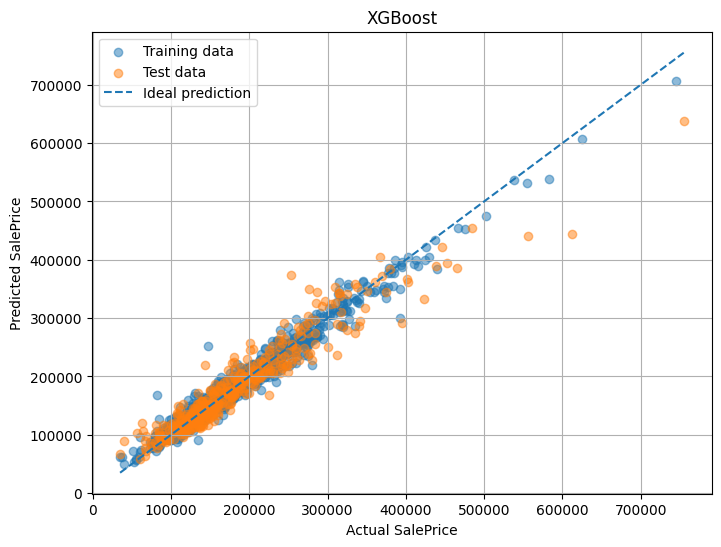

In [274]:
plot_predictions(y_train, y_train_xgb_best, y_test, y_test_xgb_best,"XGBoost")

In [275]:
results.append(
    evaluate_model("XGBoost",y_train, y_train_xgb_best, y_test, y_test_xgb_best, xgb_best_time)
)

## **4. Scikit-learn**

### 4.1 Створення моделі 

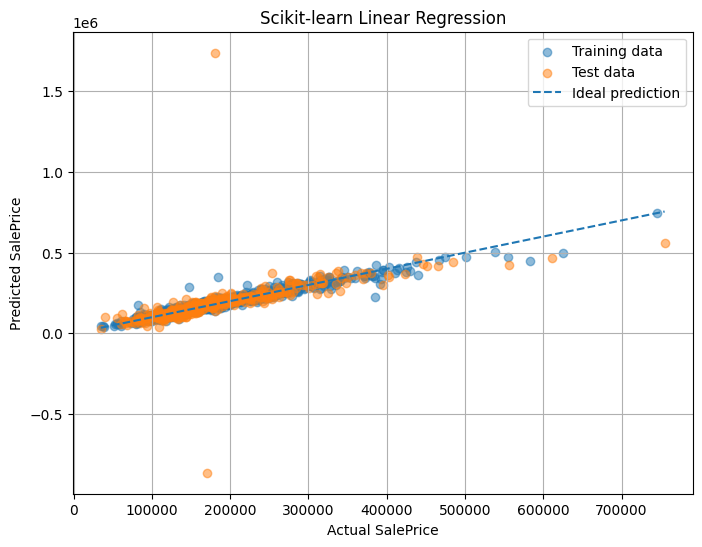

In [276]:
# Create the linear regression model.
sk_linear = LinearRegression()

# Train the model.
start_time = time.time()
sk_linear.fit(X_train_np, y_train_np)
sk_linear_time = time.time() - start_time

# Predict values for the training data.
y_train_sk_linear = sk_linear.predict(X_train_np)

# Predict values for the test data.
y_test_sk_linear = sk_linear.predict(X_test_np)

# Plot
plot_predictions( y_train, y_train_sk_linear, y_test, y_test_sk_linear, "Scikit-learn Linear Regression")

### 4.2 Створенні моделі з L1-регуляризацією

c:\Users\BOS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.884e+11, tolerance: 6.151e+08
  model = cd_fast.enet_coordinate_descent(


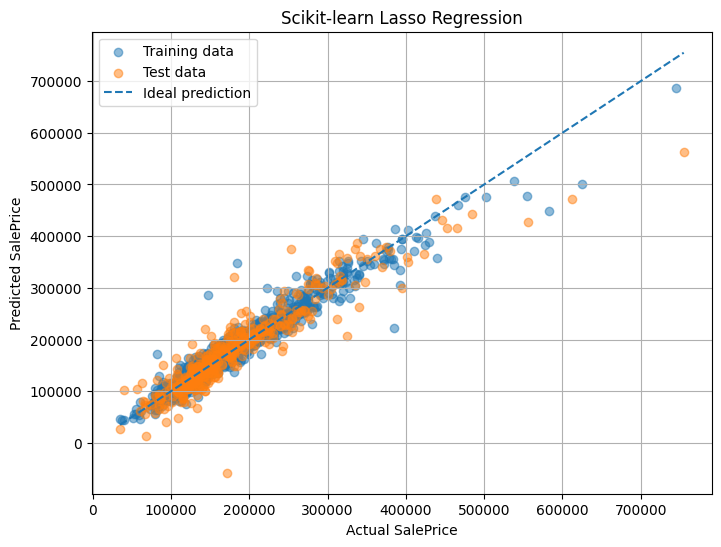

In [277]:
# Create the Lasso regression model.
sk_lasso = Lasso(alpha=0.01, max_iter=1000)

# Train the model.
start_time = time.time()
sk_lasso.fit(X_train_np, y_train_np)
sk_lasso_time = time.time() - start_time

# Predict values for the training data.
y_train_sk_lasso = sk_lasso.predict(X_train_np)

# Predict values for the test data.
y_test_sk_lasso = sk_lasso.predict(X_test_np)

# Plot
plot_predictions(y_train, y_train_sk_lasso,  y_test, y_test_sk_lasso, "Scikit-learn Lasso Regression")

### 4.3 Створенні моделі з elastic net регуляризацією

c:\Users\BOS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.936e+11, tolerance: 6.151e+08
  model = cd_fast.enet_coordinate_descent(


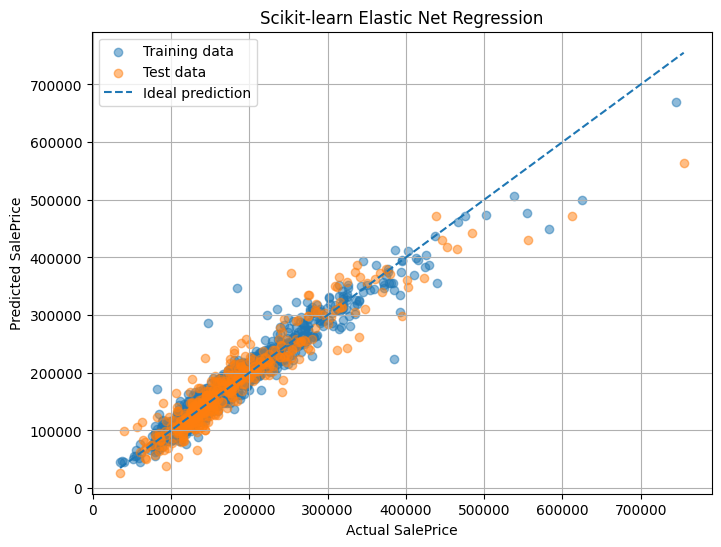

In [278]:
# Create the Elastic Net regression model.
sk_elastic = ElasticNet( alpha=0.01, l1_ratio=0.5, max_iter=1000)

# Train the model.
start_time = time.time()
sk_elastic.fit(X_train_np, y_train_np)
sk_elastic_time = time.time() - start_time

# Predict values for the training data.
y_train_sk_elastic = sk_elastic.predict(X_train_np)

# Predict values for the test data.
y_test_sk_elastic = sk_elastic.predict(X_test_np)

# Plot 
plot_predictions( y_train, y_train_sk_elastic, y_test, y_test_sk_elastic, "Scikit-learn Elastic Net Regression")

In [279]:
results.append(
    evaluate_model( "Sklearn Linear", y_train, y_train_sk_linear, y_test, y_test_sk_linear, sk_linear_time)
)
results.append(
    evaluate_model( "Sklearn Lasso", y_train, y_train_sk_lasso, y_test, y_test_sk_lasso, sk_lasso_time)
)
results.append(
    evaluate_model("Sklearn Elastic Net", y_train, y_train_sk_elastic, y_test, y_test_sk_elastic, sk_elastic_time)
)

results_df = pd.DataFrame(results)

## **5. Порівняння моделей**

In [280]:
comparison_df = results_df.copy()

comparison_df[
    [
        "Model",
        "Train MSE", "Test MSE",
        "Train RMSE", "Test RMSE",
        "Train MAE", "Test MAE",
        "Train R2", "Test R2",
        "Runtime"
    ]
]

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Runtime
0,linear Regression,3.812745e+08,7.224911e+08,19526.252680,26879.194204,12694.574002,18041.351169,0.936650,0.896463,0.540230
1,Lasso,3.812747e+08,7.224881e+08,19526.256184,26879.138821,12694.568988,18041.293312,0.936650,0.896463,0.323474
2,Elastic Net,3.820876e+08,7.212361e+08,19547.060444,26855.838576,12703.231098,17997.989848,0.936515,0.896643,0.323148
3,XGBoost,2.022395e+08,6.092221e+08,14221.093767,24682.425826,10033.739420,16173.042451,0.966397,0.912695,0.339987
4,Sklearn Linear,3.566154e+08,8.695824e+09,18884.263194,93251.400632,12088.526933,23473.766013,0.940748,-0.246160,0.095734
5,Sklearn Lasso,3.689019e+08,9.275392e+08,19206.819148,30455.527446,12433.942666,19127.683453,0.938706,0.867078,0.297465
6,Sklearn Elastic Net,3.763341e+08,7.444836e+08,19399.332297,27285.227376,12550.764272,18209.542962,0.937471,0.893311,0.284596


### 5.1 Порівняння MSE

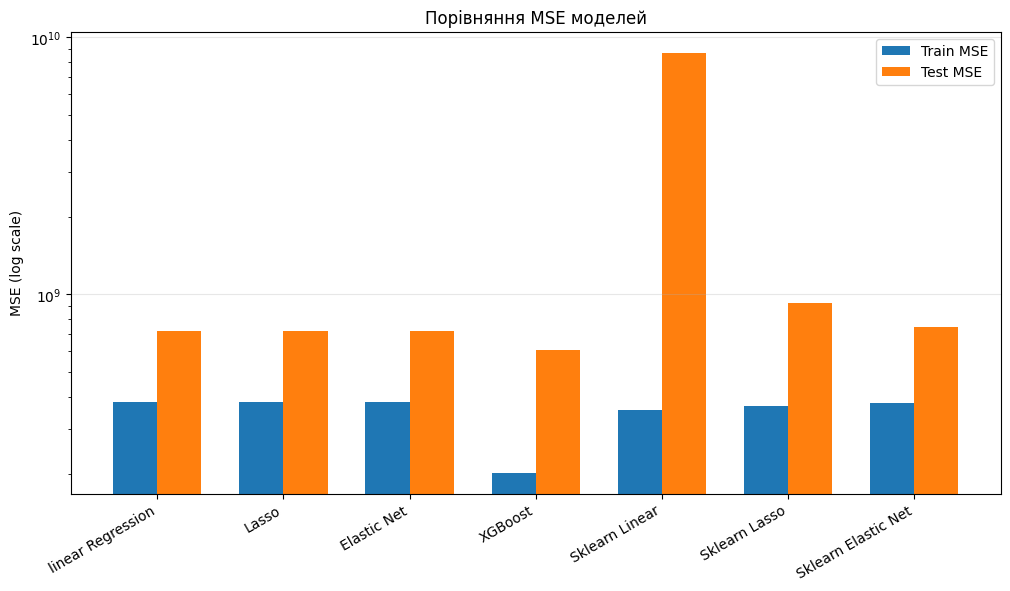

In [ ]:
# Get model names
models = comparison_df["Model"]

# Create positions for the bars
x = np.arange(len(models))

# Set the width of the bars
width = 0.35

# Create the figure
plt.figure(figsize=(12, 6))

# Plot Train MSE
plt.bar(x - width/2, comparison_df["Train MSE"], width, label="Train MSE")

# Plot Test MSE
plt.bar(x + width/2, comparison_df["Test MSE"], width, label="Test MSE")

# Use logarithmic scale for the y-axis
plt.yscale("log")

# Set model names on the x-axis
plt.xticks(x, models, rotation=30, ha="right")

plt.ylabel("MSE (log scale)")
plt.title("Comparison of MSE for Different Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

### 5.2 Порівняння RMSE

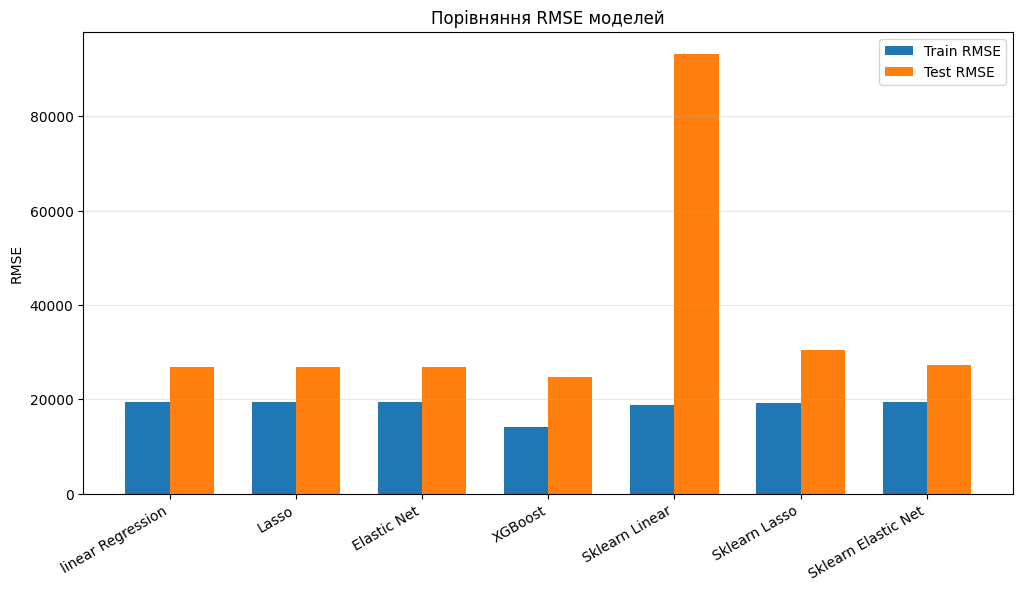

In [ ]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot Train RMSE
plt.bar(x - width/2, comparison_df["Train RMSE"], width, label="Train RMSE")

# Plot Test RMSE
plt.bar(x + width/2, comparison_df["Test RMSE"], width, label="Test RMSE")

# Set model names on the x-axis
plt.xticks(x, models, rotation=30, ha="right")

plt.ylabel("RMSE")
plt.title("Comparison of RMSE for Different Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

### 5.3 Порівняння MAE

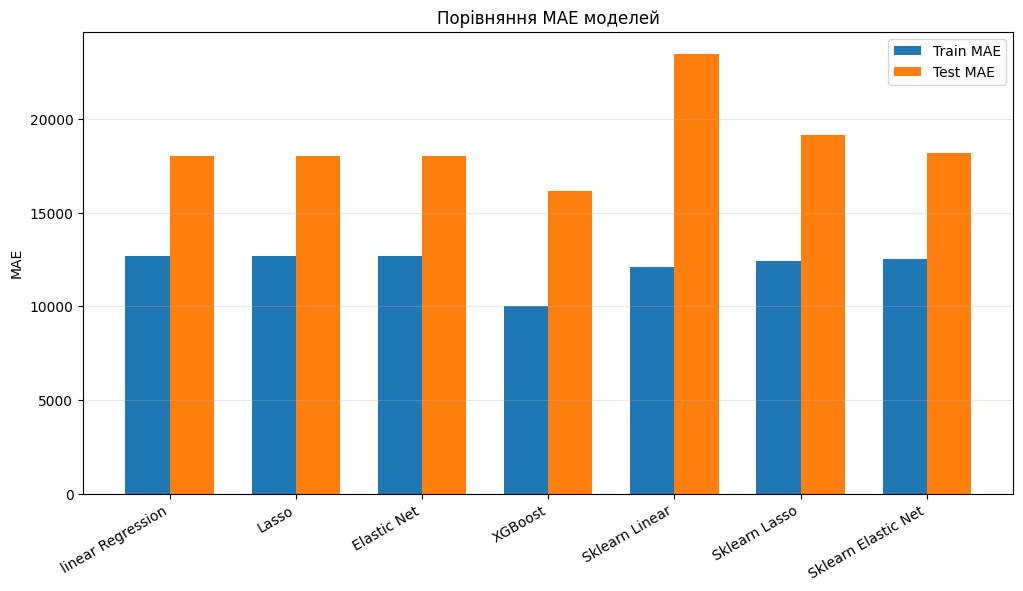

In [ ]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot Train MAE
plt.bar(x - width/2, comparison_df["Train MAE"], width, label="Train MAE")

# Plot Test MAE
plt.bar(x + width/2, comparison_df["Test MAE"], width, label="Test MAE")

# Set model names on the x-axis
plt.xticks(x, models, rotation=30, ha="right")

plt.ylabel("MAE")
plt.title("Comparison of MAE for Different Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

### 5.4 Порівняння R²

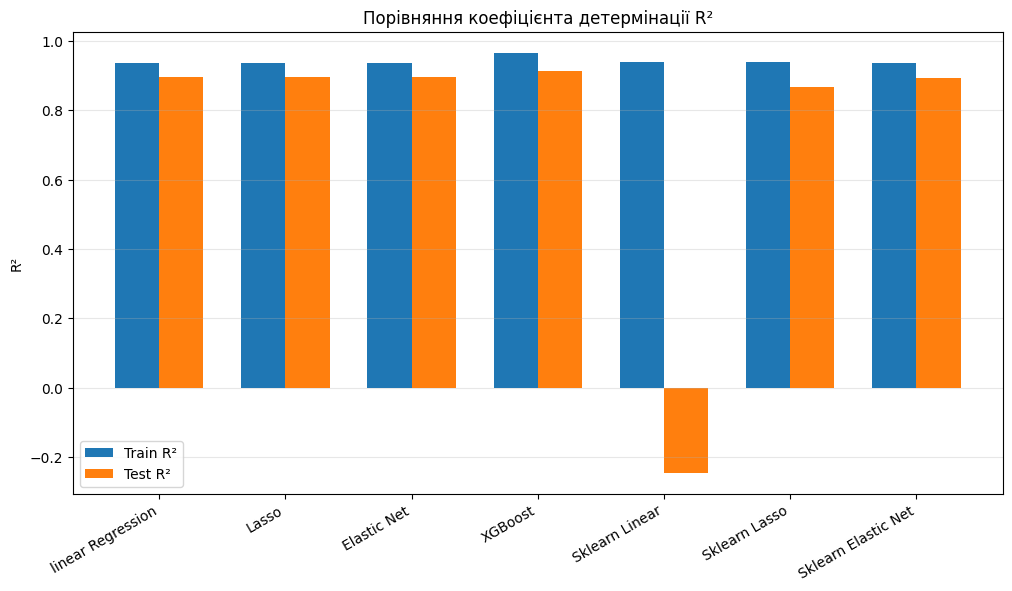

In [ ]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot Train R²
plt.bar(x - width/2, comparison_df["Train R2"], width,  label="Train R²")

# Plot Test R²
plt.bar(x + width/2, comparison_df["Test R2"], width, label="Test R²")

# Set model names on the x-axis
plt.xticks(x, models, rotation=30, ha="right")

plt.ylabel("R²")
plt.title("Comparison of R² for Different Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

### 5.5 Порівняння часу виконання

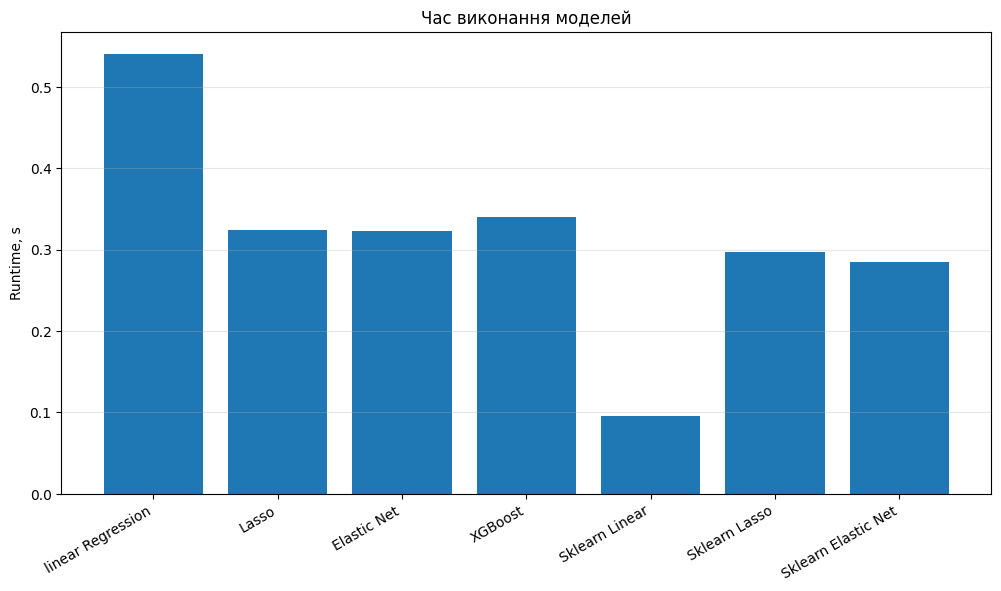

In [ ]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot runtime for each model
plt.bar(comparison_df["Model"], comparison_df["Runtime"])

# Set model names on the x-axis
plt.xticks(rotation=30, ha="right")

plt.ylabel("Runtime, s")
plt.title("Model Execution Time")
plt.grid(axis="y", alpha=0.3)